In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt
import platform

# 18 - Jaynes-Cummings Open System Dynamics

The Jaynes-Cummings Hamiltonian is written as

$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

where $\sigma_{\pm} = (\sigma_{x} \pm i\sigma_{y})/2$ are raising/lowering operators for a two-level system, $\sigma_{\mu}$ are the Pauli spin operators with $\mu\in\{x,y,z\}$, $a^{\dagger}$ and $a$ are the creation and annihilation operators for the field mode, and $\omega_{c}$, $\omega_{q}$, and $g$ are the cavity-field, qubit, and coupling (angular-) frequencies, respectively.

We will use the below parameters in our simulation

In [2]:
# parameters for the Hamiltonian
qubitFreq = 1
cavityFreq = 1
couplingFreq = 0.25
cavityDim = 5

# parameters for the evolution
totalTime = 3*(np.pi/couplingFreq)
timeStep = 0.1

and we can describe the JC-Hamiltonian/system in QuanGuru as

In [3]:
# Qubit for the JC model
QubitJC = qg.Qubit(frequency=qubitFreq)

# Cavity for the JC model
CavityJC = qg.Cavity(dimension=cavityDim, frequency=cavityFreq)

# JC model consists of a qubit and cavity
# and this is the 'free evolution' part of the JC-Hamiltonian
JCSystem = QubitJC + CavityJC

In [4]:
# coupling part of the JC-Hamiltonian
# first term of the coupling
JCCouplingT1 = JCSystem.createTerm(
    qSystem=[CavityJC, QubitJC],
    operator=[qg.destroy, qg.sigmap])

# second term of the couplings
# first term of the coupling
JCCouplingT2 = JCSystem.createTerm(
    qSystem=[QubitJC, CavityJC],
    operator=[qg.sigmam, qg.create])

# combine the terms into a single term
JCCoupling = qg.QTerm(qSystem=JCSystem,
                      subSys=[JCCouplingT1, JCCouplingT2],
                      frequency=couplingFreq)

Here, we introduce a dissipatorObj object to include cavity decay in the Lindblad master equation for evolving the JC system.

The dissipator for cavity photon decay can be described as:

$ {D}[a]\rho = a \rho  a^\dagger - \frac{1}{2} \left( a^\dagger a  \rho + \rho  a^\dagger a \right) $

where $\rho$ = density matrix of the system, a = cavity annihilation operator. 

The system evolves under both the JC Hamiltonian and the dissipative channel. This captures the irreversible loss of photons from the cavity captures via leakage to the environment.

In [5]:
# add a dissipator term for the cavity decay
cavityDissispator = qg.dissipatorObj(system=CavityJC, jOper=qg.destroy(cavityDim), jRate=.1)

# add the dissipation to the evolution of the JC system
cavityDissispator.addToProtocol(JCSystem._freeEvol)

In [6]:
# set the simulation parameters
JCSystem.simStepSize = timeStep
JCSystem.simTotalTime = totalTime

# initial state should be defined as a density matrix due to the altered evolution with dissipation. Otherwise, Quanguru will automatically convert it to a density matrix.
JCSystem.initialState = qg.densityMatrix(qg.tensorProd(qg.basis(QubitJC.dimension, 1,), qg.basis(CavityJC.dimension, 1)))

# create a frequency sweep for the cavity
freqSweep = JCSystem.simulation.Sweep.createSweep(
    system=CavityJC,
    sweepKey="frequency",
    sweepMax=qubitFreq+cavityFreq,
    sweepMin=qubitFreq-cavityFreq,
    sweepStep=.025)

In [7]:
# create sigma Z operator in the extended Hilbert space
compositeSZ = qg.compositeOp(qg.sigmaz(),   dimA=cavityDim)

# calculate the desired results and store
def compute(sim, args):
    stateJC = args[0]
    sim.resultsDict['zJC'].append(qg.expectation(compositeSZ, stateJC))

JCSystem.simCompute = compute

<span style="color:red" font-weight="bold"> IMPORTANT NOTE FOR WINDOWS USERS : MULTI-PROCESSING (p=True) DOES NOT WORK WITH NOTEBOOK

You can use a python script, but you will need to make sure that the critical parts of the code are under ``` if __name__ == "__main__": ``` We are going to add further tutorials for this later.

In [8]:
# do not store the states
JCSystem.simDelStates = True

# run the simulation
# p=True uses multi-processing for the sweep
JCSystem.runSimulation(p=(platform.system() != 'Windows'))

Starting sequential sweep with 81 parameter combinations...
Simulation Start:	2025-11-28 15:56:26
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-28 15:57:01
Simulation completed in 00h 00m 35s

[]

Text(0, 0.5, 'Time')

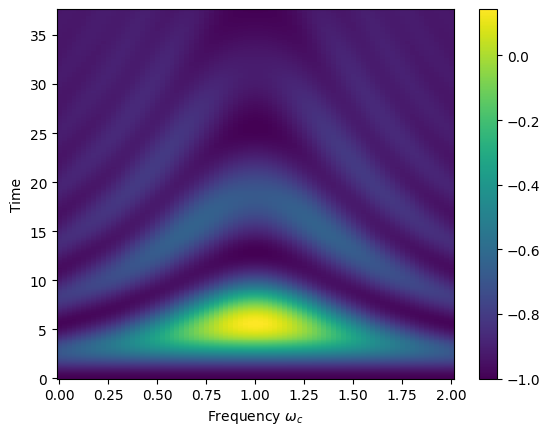

In [9]:
# Plot sigma Z expectation value as a function of time and cavity frequency
Y, X = np.meshgrid(JCSystem.simulation.timeList, freqSweep.sweepList)
plt.pcolormesh(X, Y, JCSystem.simulation.resultsDict['zJC'])
plt.colorbar()
plt.xlabel(r"Frequency $\omega_{c}$")
plt.ylabel("Time")